## SPAD ODMR — 3×3 NV Array Analysis

This notebook loads pulsed ODMR data from the SPC3 SPAD camera (identical pipeline to
`SPAD_ODMR_test`) and analyses the ODMR signal **per emitter** in the 3×3 NV array.

The 9 emitters are spaced every other pixel, occupying a 5×5 pixel footprint:

```
1 0 1 0 1
0 0 0 0 0
1 0 1 0 1
0 0 0 0 0
1 0 1 0 1
```

The mask centre (brightest pixel) is identified from the mean reference frame averaged
over all frequencies.  The reference is preferred over the signal because it carries no
ODMR dip, so all frequency points contribute equally and the brightest pixel is located
robustly.  Individual ODMR spectra are then plotted for each emitter pixel.

## Imports

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re

# Add qudi-iqo-modules to path so we can use spc.py directly (no running Qudi needed)
QUDI_MODULES = Path(r'C:\Users\SPUD1\Documents\experiment_workspace\qudi-iqo-modules\src')
if str(QUDI_MODULES) not in sys.path:
    sys.path.insert(0, str(QUDI_MODULES))

from qudi.hardware.camera.SPC3.spc_old import SPC3

plt.rcParams['figure.figsize'] = (12, 4)

In [3]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
spad_file_header = 'contacq_ODMR_test' #'test_ODMR'
qm_dir    = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-03-10\#38_pulsed_odmr_095806'

## Load metadata from QM DataHandler output (data.json / arrays.npz)

In [4]:
def _resolve_npz_ref(ref_str, base_dir):
    """Resolve a DataHandler array reference like './arrays.npz#IF_frequencies'."""
    if isinstance(ref_str, str) and '#' in ref_str:
        file_part, key = ref_str.split('#', 1)
        npz_path = (Path(base_dir) / file_part).resolve()
        return np.load(npz_path)[key]
    return ref_str

qm_dir = Path(qm_dir)
with open(qm_dir / 'data.json', 'r') as f:
    meta = json.load(f)

# Resolve IF_frequencies (may be an npz reference)
if_raw = meta.get('IF_frequencies')
f_vec = np.asarray(_resolve_npz_ref(if_raw, qm_dir), dtype=float)

n_avg = int(meta.get('n_avg', 1))
# 'iteration' is 0-indexed: value 0 → 1 completed, 99999 → 100000 completed
# Falls back to n_avg when the field is absent (n_avg - 1 + 1 = n_avg)
n_iteration = int(meta.get('iteration', n_avg - 1)) + 1

print(f"n_avg        : {n_avg}  (requested)")
print(f"n_iteration  : {n_iteration}  (actually completed)")
if n_iteration != n_avg:
    print(f"  ↳ experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target")
print(f"len(f_vec)   : {len(f_vec)}")
print(f"f_vec range  : {f_vec.min()/1e6:.1f} – {f_vec.max()/1e6:.1f} MHz")
print(f"Expected total frames: {2 * n_iteration * len(f_vec)}")

n_avg        : 100000  (requested)
n_iteration  : 100000  (actually completed)
len(f_vec)   : 40
f_vec range  : 70.0 – 89.5 MHz
Expected total frames: 8000000


## Load SPC3 files — streaming accumulation with background subtraction

Files are processed one at a time in their native `uint8`/`uint16` dtype.  Each file's frames are
immediately demuxed into signal and reference `float64` accumulators of shape `(F, rows, cols)`, then
discarded.  Peak RAM usage is one file at a time plus two small accumulators — independent of total
recording length.  A carry buffer handles rep boundaries that fall mid-file.

If a background sidecar `<header>.bg.npy` is found next to the `.spc3` files (saved automatically
by qudi when background subtraction is enabled at acquisition time), it is subtracted from every
frame **before** accumulation, with the result clamped to zero.  This ensures the ODMR contrast is
computed on background-free counts.

In [5]:
spad_dir_path = Path(spad_dir)

# -----------------------------------------------------------------
# Discover all part-files matching <header>.spc3, <header>2.spc3, ...
# Only digits (never other text) may follow the header — this prevents
# "ODMR_test_new.spc3" being picked up when header is "ODMR_test".
# -----------------------------------------------------------------
def _spc3_sort_key(p):
    m = re.search(r'(\d+)\.spc3$', p.name, re.IGNORECASE)
    return int(m.group(1)) if m else 0

_part_re = re.compile(
    r'^' + re.escape(spad_file_header) + r'\d*\.spc3$',
    re.IGNORECASE
)

spc3_files = sorted(
    (p for p in spad_dir_path.glob(f'{spad_file_header}*.spc3') if _part_re.match(p.name)),
    key=_spc3_sort_key
)

if not spc3_files:
    raise FileNotFoundError(
        f"No SPC3 files found matching '{spad_file_header}[<digits>].spc3' in\n  {spad_dir_path}"
    )

print(f"Found {len(spc3_files)} SPC3 file(s):")
for fp in spc3_files:
    print(f"  {fp.name}")

# -----------------------------------------------------------------
# Load background sidecar (.bg.npy) if present alongside the .spc3 files.
# -----------------------------------------------------------------
bg_sidecar = spad_dir_path / (spad_file_header + '.bg.npy')
if bg_sidecar.exists():
    background = np.load(bg_sidecar).astype(np.float64)   # (rows, cols)
    print(f"\nBackground sidecar loaded: {bg_sidecar.name}  shape={background.shape}")
else:
    background = None
    print(f"\nNo background sidecar found ({bg_sidecar.name}) — skipping subtraction.")
    print("  To enable: in qudi, click 'Capture Background' THEN toggle 'Background Subtraction' ON before acquisition.")

# -----------------------------------------------------------------
# Streaming accumulation
# -----------------------------------------------------------------
F              = len(f_vec)
frames_per_rep = 2 * F

header          = None
sig_sum         = None   # (F, rows, cols) float64
ref_sum         = None   # (F, rows, cols) float64
n_complete_reps = 0
n_rows = n_cols = None
carry           = None
N_frames_raw    = 0

for fp in spc3_files:
    f_data, h = SPC3.ReadSPC3DataFile(str(fp))
    frames = f_data[0]          # (N, rows, cols) — native uint8 or uint16
    N_frames_raw += frames.shape[0]

    if header is None:
        header = h
        n_rows, n_cols = frames.shape[1], frames.shape[2]
        print(f"\nRaw frame dtype      : {frames.dtype}")
        sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
        ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)

        if background is not None and background.shape != (n_rows, n_cols):
            print(f"WARNING: background shape {background.shape} != frame shape "
                  f"({n_rows}, {n_cols}) — disabling background subtraction")
            background = None

    if carry is not None:
        frames = np.concatenate([carry, frames], axis=0)
        carry = None

    n_frames        = frames.shape[0]
    n_complete_here = (n_frames // frames_per_rep) * frames_per_rep

    if n_complete_here > 0:
        batch = frames[:n_complete_here].astype(np.float64)

        if background is not None:
            batch = np.maximum(batch - background[np.newaxis, :, :], 0.0)

        rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)
        sig_sum += rep_view[:, :, 0, :, :].sum(axis=0)
        ref_sum += rep_view[:, :, 1, :, :].sum(axis=0)
        n_complete_reps += n_complete_here // frames_per_rep

    if n_frames > n_complete_here:
        carry = frames[n_complete_here:]

    print(f"  {fp.name}: {n_complete_here} frames used  "
          f"(running total: {n_complete_reps} complete reps)")

dropped = N_frames_raw - n_complete_reps * frames_per_rep
print(f"\nTotal frames raw     : {N_frames_raw}")
print(f"Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
if dropped:
    print(f"Dropped trailing     : {dropped} frame(s) (incomplete final repetition)")
print(f"Background subtracted: {'yes' if background is not None else 'no'}")
print(f"Accumulator dtype    : {sig_sum.dtype}  shape: {sig_sum.shape}")
print(f"HwIntTime            : {header.HwIntTime*1e9:.1f} ns  ({header.SummedFrames} summed frames in hw)")

gate_on       = header.CoarseGate_C1_ON
gate_start_ns = header.CoarseGate_C1_startPos * 1e9
gate_stop_ns  = header.CoarseGate_C1_stopPos  * 1e9
if gate_on:
    print(f"CoarseGate C1        : ON  start={gate_start_ns:.0f} ns  stop={gate_stop_ns:.0f} ns")
else:
    print(f"CoarseGate C1        : OFF")

Found 8 SPC3 file(s):
  contacq_ODMR_test.spc3
  contacq_ODMR_test2.spc3
  contacq_ODMR_test3.spc3
  contacq_ODMR_test4.spc3
  contacq_ODMR_test5.spc3
  contacq_ODMR_test6.spc3
  contacq_ODMR_test7.spc3
  contacq_ODMR_test8.spc3

No background sidecar found (contacq_ODMR_test.bg.npy) — skipping subtraction.
  To enable: in qudi, click 'Capture Background' THEN toggle 'Background Subtraction' ON before acquisition.

Raw frame dtype      : uint8
  contacq_ODMR_test.spc3: 1048560 frames used  (running total: 13107 complete reps)
  contacq_ODMR_test2.spc3: 1048560 frames used  (running total: 26214 complete reps)
  contacq_ODMR_test3.spc3: 1048560 frames used  (running total: 39321 complete reps)
  contacq_ODMR_test4.spc3: 1048560 frames used  (running total: 52428 complete reps)
  contacq_ODMR_test5.spc3: 1048560 frames used  (running total: 65535 complete reps)
  contacq_ODMR_test6.spc3: 1048640 frames used  (running total: 78643 complete reps)
  contacq_ODMR_test7.spc3: 1048560 frames u

## Compute per-frequency averages

In [64]:
if n_complete_reps == 0:
    raise RuntimeError("No complete repetitions found — check spad_file_header and f_vec length.")

sig_avg  = sig_sum / n_complete_reps   # (F, rows, cols) float64
ref_avg  = ref_sum / n_complete_reps   # (F, rows, cols) float64
diff_avg = sig_avg - ref_avg           # (F, rows, cols) float64

print(f"n_complete_reps  : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
print(f"sig_avg shape    : {sig_avg.shape}  dtype: {sig_avg.dtype}")
print(f"Mean counts/px   : sig={sig_avg.mean():.4f}  ref={ref_avg.mean():.4f}")

n_complete_reps  : 384571  (384.6% of 100000 completed, 100000 requested)
sig_avg shape    : (40, 32, 32)  dtype: float64
Mean counts/px   : sig=0.0014  ref=0.0015


## Total all-pixel ODMR spectrum (cross-check with SPAD_ODMR_test)

Sum all pixels at each frequency to produce the headline ODMR spectrum — identical
pipeline to `SPAD_ODMR_test`.  This serves as the ground-truth reference: the
per-emitter spectra extracted below should show the same resonance position and
equal or higher contrast (fewer background pixels diluting the signal).

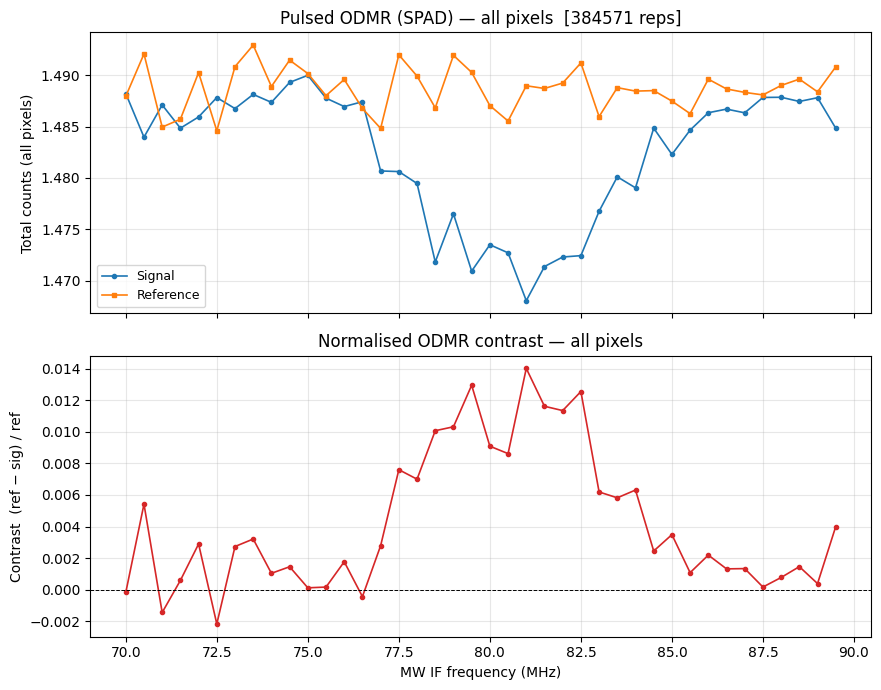

Peak contrast (all pixels): 0.0140  @ 81.00 MHz
Signal range : 1 – 1 counts
Ref range    : 1 – 1 counts


In [65]:
f_mhz = f_vec / 1e6

# Sum all pixels at each frequency — identical to SPAD_ODMR_test
sig_counts  = sig_avg.sum(axis=(-1, -2))   # (F,)
ref_counts  = ref_avg.sum(axis=(-1, -2))   # (F,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_all = np.where(ref_counts != 0, (ref_counts - sig_counts) / ref_counts, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(f_mhz, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(f_mhz, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
axes[0].set_ylabel('Total counts (all pixels)')
axes[0].set_title(f'Pulsed ODMR (SPAD) — all pixels  [{n_complete_reps} reps]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_mhz, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.7, ls='--')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised ODMR contrast — all pixels')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peak contrast (all pixels): {contrast_all.max():.4f}  @ {f_mhz[np.argmax(contrast_all)]:.2f} MHz")
print(f"Signal range : {sig_counts.min():.0f} – {sig_counts.max():.0f} counts")
print(f"Ref range    : {ref_counts.min():.0f} – {ref_counts.max():.0f} counts")

## Identify emitter mask from mean reference frame

The brightest pixel in the mean reference frame (averaged over all frequencies) is
taken as the centre of the 3×3 NV array.  Using the mean reference rather than a
single signal frame avoids mis-identification when any one frequency happens to
fall near the ODMR resonance (where the signal is suppressed).  The 9 emitter
pixels are then indexed at every-other-pixel offsets (±2 in row and col) from
this centre.

Array centre (brightest pixel in ref_avg.mean): row=14, col=16
  NV(0,0): pixel (12, 14)  OK
  NV(0,1): pixel (12, 16)  OK
  NV(0,2): pixel (12, 18)  OK
  NV(1,0): pixel (14, 14)  OK
  NV(1,1): pixel (14, 16)  OK
  NV(1,2): pixel (14, 18)  OK
  NV(2,0): pixel (16, 14)  OK
  NV(2,1): pixel (16, 16)  OK
  NV(2,2): pixel (16, 18)  OK


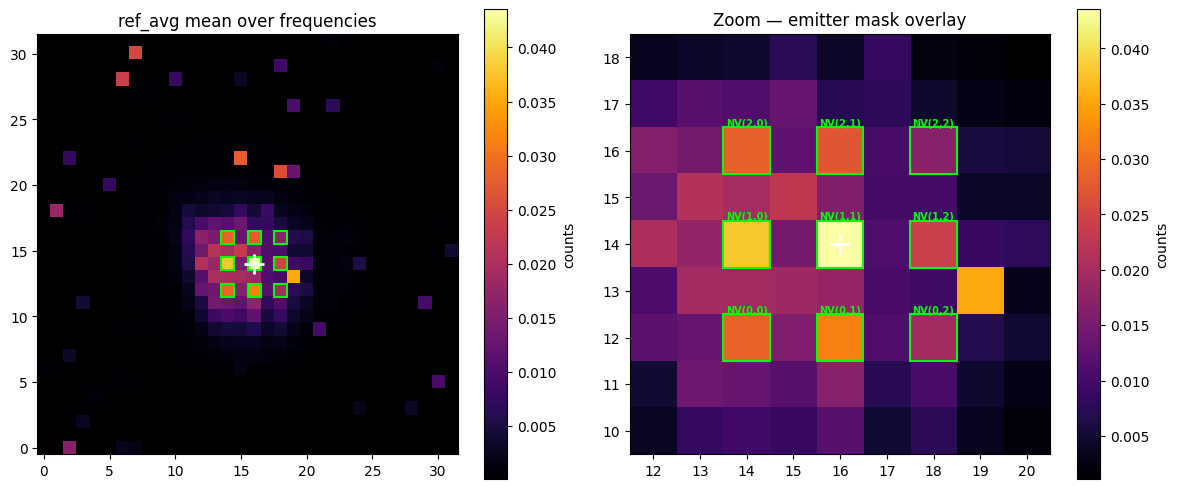

In [66]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
# ref_avg has no ODMR dip, so every frequency contributes equally — more robust than
# using a single signal frame that may be suppressed near resonance.
ref_frame = ref_avg.mean(axis=0)  # (rows, cols) — mean reference over all frequencies
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

# 3×3 emitter mask: every other pixel → 5×5 footprint
# Offsets from centre pixel: -2, 0, +2 in both row and col
EMITTER_OFFSETS = [(-2, -2), (-2, 0), (-2, 2),
                   ( 0, -2), ( 0, 0), ( 0, 2),
                   ( 2, -2), ( 2, 0), ( 2, 2)]

# Label each emitter position in the 3×3 grid
EMITTER_LABELS = ['NV(0,0)', 'NV(0,1)', 'NV(0,2)',
                  'NV(1,0)', 'NV(1,1)', 'NV(1,2)',
                  'NV(2,0)', 'NV(2,1)', 'NV(2,2)']

# Compute absolute (row, col) for each emitter
emitter_pixels = [(bright_rc[0] + dr, bright_rc[1] + dc) for dr, dc in EMITTER_OFFSETS]

# Verify all pixels are inside the frame
for lbl, (r, c) in zip(EMITTER_LABELS, emitter_pixels):
    inside = 0 <= r < n_rows and 0 <= c < n_cols
    print(f'  {lbl}: pixel ({r:2d}, {c:2d})  {"OK" if inside else "OUT OF BOUNDS"}')

# Show the mask on the reference frame
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(ref_frame, origin='lower', cmap='inferno')
axes[0].set_title('ref_avg mean over frequencies')
fig.colorbar(im0, ax=axes[0], label='counts')

# Zoom view around the emitter array
pad = 4
r_lo = max(bright_rc[0] - pad, 0)
r_hi = min(bright_rc[0] + pad + 1, n_rows)
c_lo = max(bright_rc[1] - pad, 0)
c_hi = min(bright_rc[1] + pad + 1, n_cols)
im1 = axes[1].imshow(ref_frame[r_lo:r_hi, c_lo:c_hi], origin='lower', cmap='inferno',
                     extent=[c_lo - 0.5, c_hi - 0.5, r_lo - 0.5, r_hi - 0.5])
axes[1].set_title('Zoom — emitter mask overlay')
fig.colorbar(im1, ax=axes[1], label='counts')

# Overlay mask rectangles and labels
for ax in axes:
    for lbl, (r, c) in zip(EMITTER_LABELS, emitter_pixels):
        rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                              linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    # Mark centre
    ax.plot(bright_rc[1], bright_rc[0], 'w+', ms=14, mew=2)

# Add text labels on zoom view
for lbl, (r, c) in zip(EMITTER_LABELS, emitter_pixels):
    axes[1].text(c, r + 0.7, lbl, ha='center', va='top', fontsize=7,
                 color='lime', fontweight='bold')


plt.tight_layout()
plt.show()

## Per-emitter ODMR spectra

Extract the signal and reference counts at each emitter pixel across all frequencies,
then plot individual ODMR spectra (raw counts and normalised contrast) for each of the
9 NV centres.

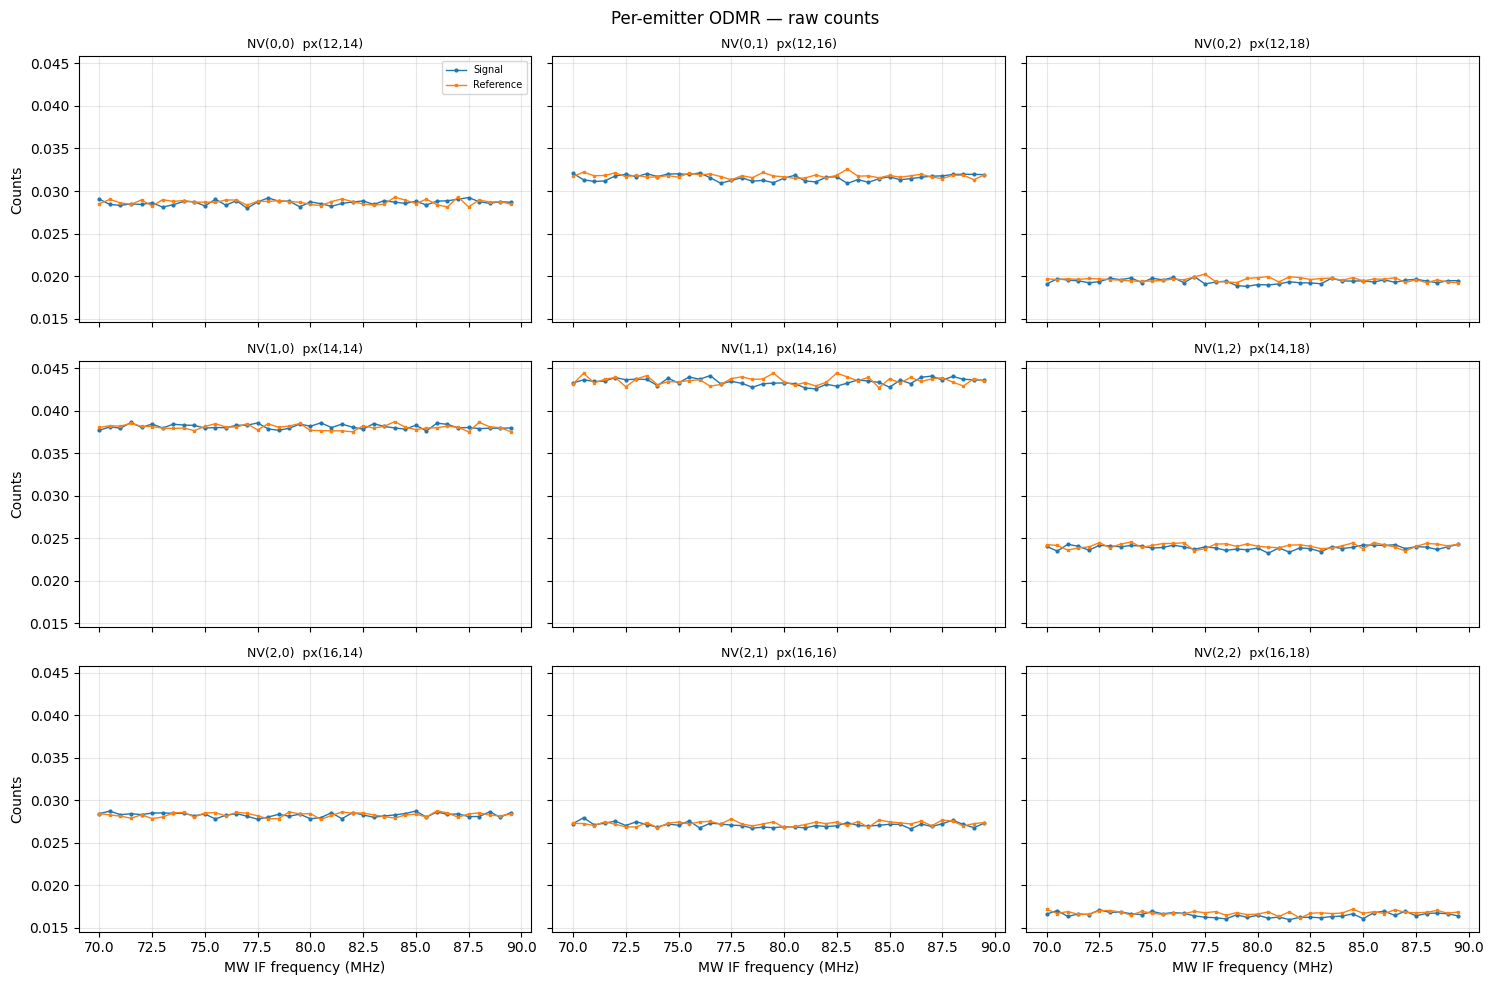

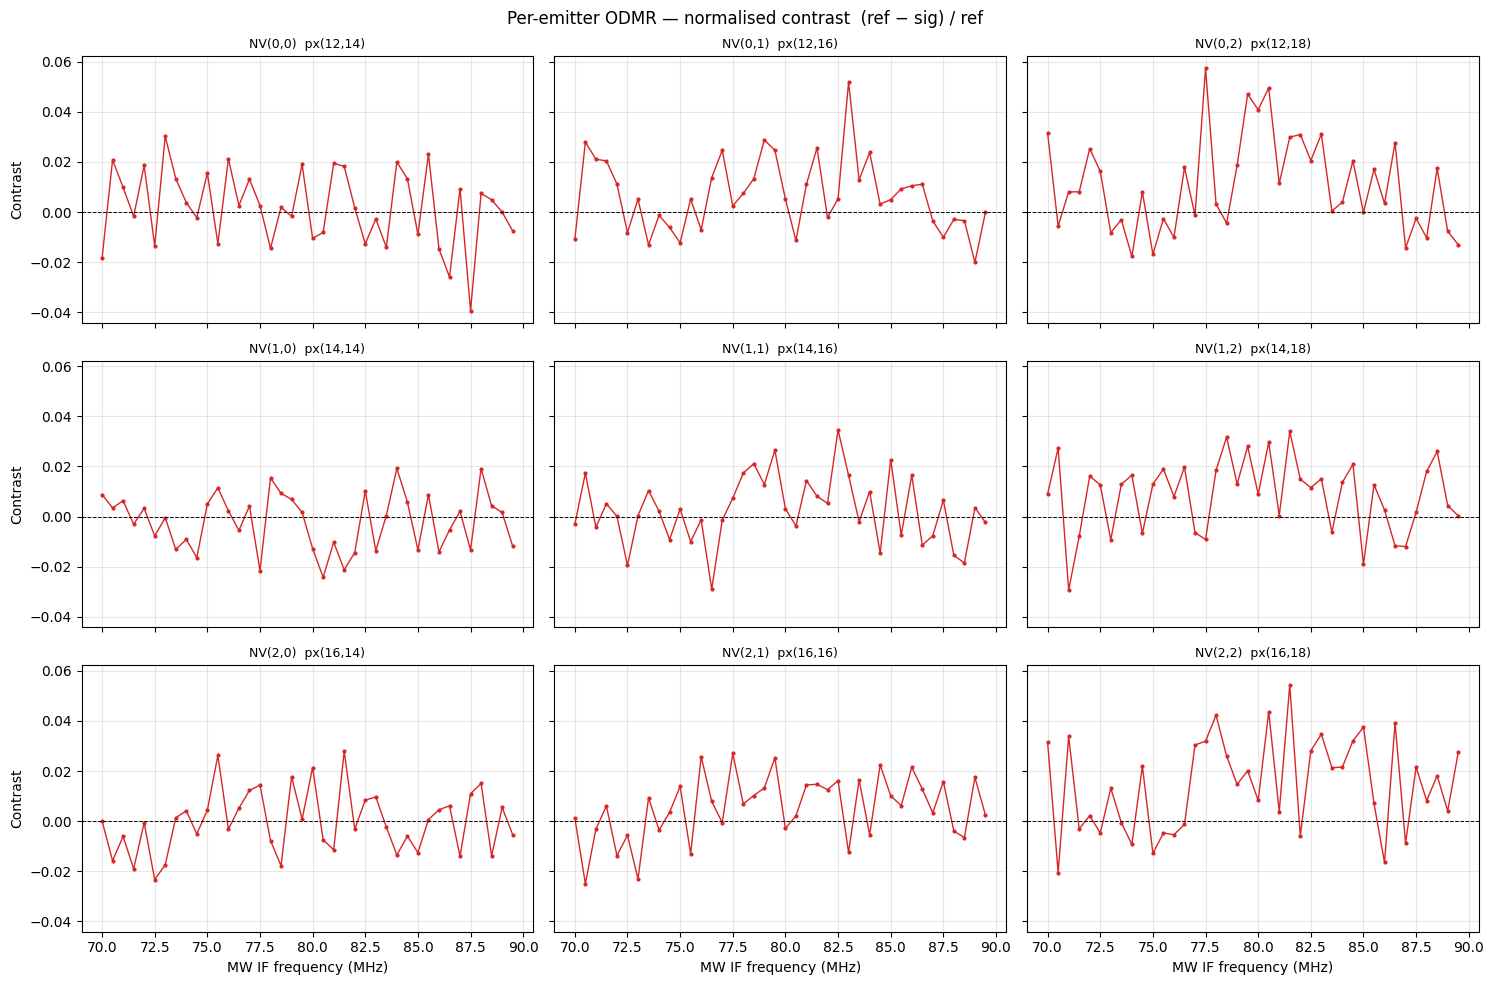


Emitter         Pixel   Peak contrast   @ freq (MHz)    Mean sig    Mean ref
---------------------------------------------------------------------------
NV(0,0)      (12,14)          0.0302          73.00      0.0286      0.0287
NV(0,1)      (12,16)          0.0519          83.00      0.0316      0.0318
NV(0,2)      (12,18)          0.0573          77.50      0.0194      0.0196
NV(1,0)      (14,14)          0.0192          84.00      0.0381      0.0380
NV(1,1)      (14,16)          0.0346          82.50      0.0434      0.0435
NV(1,2)      (14,18)          0.0340          81.50      0.0239      0.0241
NV(2,0)      (16,14)          0.0279          81.50      0.0283      0.0283
NV(2,1)      (16,16)          0.0270          77.50      0.0271      0.0273
NV(2,2)      (16,18)          0.0543          81.50      0.0165      0.0168


In [67]:
# Extract per-emitter time-series: shape (9, F)
emitter_sig = np.zeros((9, F))
emitter_ref = np.zeros((9, F))
for idx, (r, c) in enumerate(emitter_pixels):
    if 0 <= r < n_rows and 0 <= c < n_cols:
        emitter_sig[idx] = sig_avg[:, r, c]
        emitter_ref[idx] = ref_avg[:, r, c]

# Normalised contrast per emitter: (ref - sig) / ref
with np.errstate(divide='ignore', invalid='ignore'):
    emitter_contrast = np.where(emitter_ref != 0,
                                (emitter_ref - emitter_sig) / emitter_ref, 0.0)

# --- 3×3 grid of ODMR spectra (raw counts) ---
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
fig.suptitle('Per-emitter ODMR — raw counts', fontsize=12)

for idx in range(9):
    ax = axes[idx // 3, idx % 3]
    ax.plot(f_mhz, emitter_sig[idx], 'o-', ms=2, lw=1, label='Signal')
    ax.plot(f_mhz, emitter_ref[idx], 's-', ms=2, lw=1, label='Reference')
    r, c = emitter_pixels[idx]
    ax.set_title(f'{EMITTER_LABELS[idx]}  px({r},{c})', fontsize=9)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

for ax in axes[-1, :]:
    ax.set_xlabel('MW IF frequency (MHz)')
for ax in axes[:, 0]:
    ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

# --- 3×3 grid of ODMR spectra (normalised contrast) ---
fig2, axes2 = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
fig2.suptitle('Per-emitter ODMR — normalised contrast  (ref − sig) / ref', fontsize=12)

for idx in range(9):
    ax = axes2[idx // 3, idx % 3]
    ax.plot(f_mhz, emitter_contrast[idx], 'o-', ms=2, lw=1, color='C3')
    ax.axhline(0, color='k', lw=0.7, ls='--')
    r, c = emitter_pixels[idx]
    ax.set_title(f'{EMITTER_LABELS[idx]}  px({r},{c})', fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes2[-1, :]:
    ax.set_xlabel('MW IF frequency (MHz)')
for ax in axes2[:, 0]:
    ax.set_ylabel('Contrast')

plt.tight_layout()
plt.show()

# Print summary
print(f'\n{"Emitter":<12} {"Pixel":>8}  {"Peak contrast":>14}  {"@ freq (MHz)":>13}  {"Mean sig":>10}  {"Mean ref":>10}')
print('-' * 75)
for idx in range(9):
    r, c = emitter_pixels[idx]
    pk = emitter_contrast[idx].max()
    pk_f = f_mhz[emitter_contrast[idx].argmax()]
    ms = emitter_sig[idx].mean()
    mr = emitter_ref[idx].mean()
    print(f'{EMITTER_LABELS[idx]:<12} ({r:2d},{c:2d})  {pk:14.4f}  {pk_f:13.2f}  {ms:10.4f}  {mr:10.4f}')

## Combined 9-emitter ODMR (integrated mask)

Sum the signal and reference counts across all 9 emitter pixels to produce a single
ODMR spectrum with improved SNR compared to individual pixels.

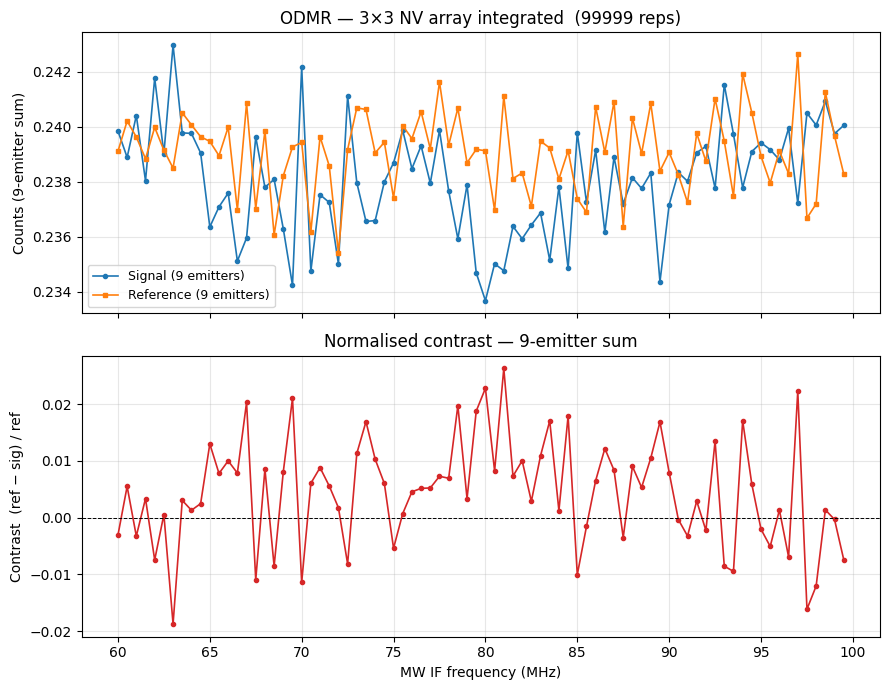


Peak contrast (9-emitter): 0.0263  @ 81.00 MHz
Signal range : 0.2 – 0.2 counts
Ref range    : 0.2 – 0.2 counts


In [24]:
# Sum across all 9 emitters
sig_mask_total = emitter_sig.sum(axis=0)   # (F,)
ref_mask_total = emitter_ref.sum(axis=0)   # (F,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_mask = np.where(ref_mask_total != 0,
                             (ref_mask_total - sig_mask_total) / ref_mask_total, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(f_mhz, sig_mask_total, 'o-', ms=3, lw=1.2, label='Signal (9 emitters)')
axes[0].plot(f_mhz, ref_mask_total, 's-', ms=3, lw=1.2, label='Reference (9 emitters)')
axes[0].set_ylabel('Counts (9-emitter sum)')
axes[0].set_title(f'ODMR — 3×3 NV array integrated  ({n_complete_reps} reps)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_mhz, contrast_mask, 'o-', ms=3, lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.7, ls='--')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised contrast — 9-emitter sum')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPeak contrast (9-emitter): {contrast_mask.max():.4f}  @ {f_mhz[np.argmax(contrast_mask)]:.2f} MHz")
print(f"Signal range : {sig_mask_total.min():.1f} – {sig_mask_total.max():.1f} counts")
print(f"Ref range    : {ref_mask_total.min():.1f} – {ref_mask_total.max():.1f} counts")